# 02 — Preprocessing

Limpieza de minutas, parsing de fechas, construcción de etiquetas (`hike` / `cut` / `hold`) a partir de la variación de la federal funds target rate (FRED).

**Inputs:**
- `data/raw/minutes/` — archivos .txt scrapeados en el notebook 01 (usamos el rango **2000–2025**)
- FRED — series `DFEDTAR` (pre-2008) y `DFEDTARU` (post-2008)

**Output:** `data/processed/fomc_dataset.csv` — columnas `[date, text, label, split]`

In [1]:
import pandas as pd
import numpy as np
import html as html_lib
import string
import requests
from io import StringIO
from pathlib import Path

import nltk

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Rutas
BASE_DIR       = Path('..').resolve()
DATA_RAW       = BASE_DIR / 'data' / 'raw'
DATA_PROCESSED = BASE_DIR / 'data' / 'processed'
MINUTES_DIR    = DATA_RAW / 'minutes'
RATES_DIR      = DATA_RAW / 'rates'

DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
RATES_DIR.mkdir(parents=True, exist_ok=True)

n_minutes = len(list(MINUTES_DIR.glob('*.txt')))
print(f'Entorno configurado. Minutas en disco: {n_minutes}')

Entorno configurado. Minutas en disco: 884


## 1. Descarga de tasas FRED

La Fed publica la federal funds target rate en FRED:
- **DFEDTAR** (2000–2008): tasa única (régimen pre-2008).
- **DFEDTARU** (2008–2025): cota superior del rango (régimen post-2008); usamos la cota superior como proxy del target.

Descargamos directamente el CSV público de FRED via `requests` (sin `pandas_datareader`, incompatible con Python 3.14). Los labels emergen del diff entre fechas de minutas consecutivas.

Serie diaria: 2000-01-01 -> 2025-12-31
Rango de tasas: 0.25% - 6.50%


<Axes: title={'center': 'Federal Funds Target Rate (FRED)'}, xlabel='observation_date', ylabel='% anual'>

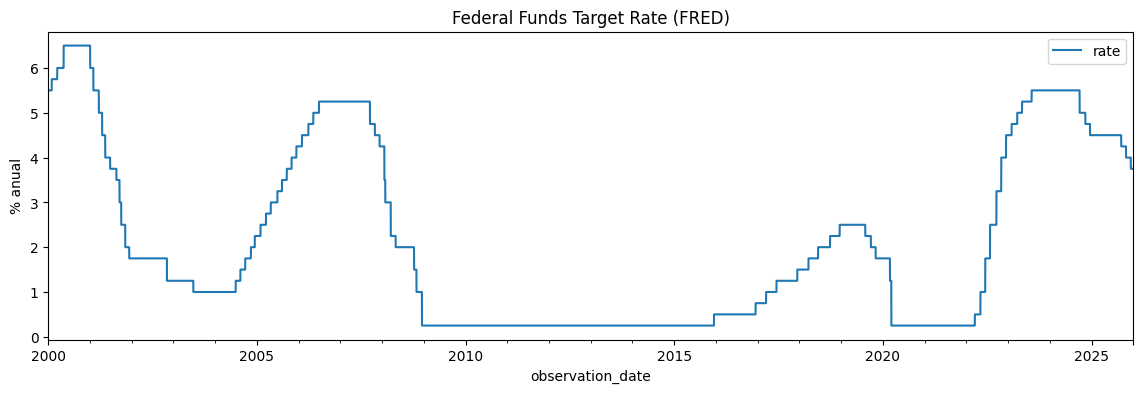

In [2]:
def download_fred(series_id):
    url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}'
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    df = pd.read_csv(StringIO(resp.text), na_values=['.'])
    # FRED CSV usa 'observation_date' como nombre de columna
    date_col = df.columns[0]
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.set_index(date_col)
    df.columns = ['rate']
    df['rate'] = pd.to_numeric(df['rate'], errors='coerce')
    return df.dropna()

# Pre-2008: tasa única
dfedtar  = download_fred('DFEDTAR')['2000-01-01':'2008-12-31']

# Post-2008: cota superior del rango (corpus extendido hasta 2025)
dfedtaru = download_fred('DFEDTARU')['2008-12-01':'2025-12-31']

# Concatenar, eliminar solapamiento, remuestrear a diario con forward fill
raw_series  = pd.concat([dfedtar, dfedtaru]).sort_index()
raw_series  = raw_series[~raw_series.index.duplicated(keep='last')]
target_rate = raw_series.resample('D').last().ffill()

# Guardar para reproducibilidad
target_rate.to_csv(RATES_DIR / 'fred_target_rate.csv')

start = target_rate.index[0].date()
end   = target_rate.index[-1].date()
rmin  = target_rate['rate'].min()
rmax  = target_rate['rate'].max()
print(f'Serie diaria: {start} -> {end}')
print(f'Rango de tasas: {rmin:.2f}% - {rmax:.2f}%')

target_rate.plot(figsize=(14, 4), title='Federal Funds Target Rate (FRED)', ylabel='% anual')

## 2. Carga de minutas

Cargamos las minutas en el rango **2000–2025**. El nombre del archivo codifica la fecha de la **reunión** (no la fecha de publicación, que es ~3 semanas después). Los archivos fuera de rango se descartan.

In [3]:
records = []
for path in sorted(MINUTES_DIR.glob('*.txt')):
    date_str = path.stem.replace('_minutes', '')
    try:
        date = pd.to_datetime(date_str)
    except Exception:
        continue
    if date.year < 2000 or date.year > 2025:
        continue
    text = path.read_text(encoding='utf-8', errors='replace')
    records.append({'date': date, 'text': text})

df = pd.DataFrame(records).sort_values('date').reset_index(drop=True)
print(f'Minutas cargadas: {len(df)}')
print(f"Rango: {df['date'].min().date()} -> {df['date'].max().date()}")
df[['date']].head()

Minutas cargadas: 209
Rango: 2000-02-02 -> 2025-12-10


,date
0,2000-02-02
1,2000-03-21
2,2000-05-16
3,2000-06-28
4,2000-08-22


## 3. Construcción de etiquetas

La etiqueta de cada minuta refleja **la decisión tomada en esa reunión**. Comparamos la tasa
vigente **antes** de la reunión (día previo) con la vigente **después** (≈1 semana, para dar
margen a que la nueva tasa entre en vigencia el día hábil siguiente):
- **hike**: `rate_after > rate_before`
- **cut**: `rate_after < rate_before`
- **hold**: `rate_after == rate_before`

Este criterio (antes vs después de la **misma** reunión) es el descrito en el informe y evita el
desfasaje de comparar reuniones consecutivas, que atribuiría la decisión a la reunión siguiente.
`asof()` garantiza un valor válido aunque la fecha caiga en fin de semana o feriado.

In [4]:
rate_series = target_rate['rate']

# La etiqueta de cada reunión refleja LA DECISIÓN TOMADA EN ESA reunión: comparamos la tasa
# vigente justo ANTES de la reunión con la vigente DESPUÉS. El anuncio del FOMC es el día de la
# reunión y la nueva tasa rige ~1 día hábil después; usamos +7 días de margen (fines de semana/
# feriados) y -1 día para el valor previo. Las reuniones distan ~6-8 semanas, así que +7 días no
# se solapa con la reunión siguiente.
DAYS_AFTER = 7

df['rate_before'] = df['date'].apply(lambda d: rate_series.asof(d - pd.Timedelta(days=1)))
df['rate_after']  = df['date'].apply(lambda d: rate_series.asof(d + pd.Timedelta(days=DAYS_AFTER)))
df['delta']       = df['rate_after'] - df['rate_before']

def assign_label(row):
    if row['delta'] > 0:
        return 'hike'
    if row['delta'] < 0:
        return 'cut'
    return 'hold'

df['label'] = df.apply(assign_label, axis=1)

print('Distribucion de etiquetas:')
print(df['label'].value_counts())

Distribucion de etiquetas:
label
hold    141
hike     40
cut      28
Name: count, dtype: int64


In [5]:
# Sanity check: verificar contra eventos historicos conocidos
check = df[['date', 'rate_before', 'rate_after', 'delta', 'label']].copy()

print('--- Recortes 2007-2009 (esperado: varios cut) ---')
mask = (check['date'] >= '2007-09-01') & (check['date'] <= '2009-07-01')
print(check[mask].to_string(index=False))

print()
print('--- 2022 en adelante (esperado: hikes 2022-23, holds, y cuts en 2024) ---')
mask2 = check['date'] >= '2022-01-01'
print(check[mask2].to_string(index=False))

--- Recortes 2007-2009 (esperado: varios cut) ---
      date  rate_before  rate_after  delta label
2007-09-18         5.25        4.75  -0.50   cut
2007-10-31         4.75        4.50  -0.25   cut
2007-12-11         4.50        4.25  -0.25   cut
2008-01-30         3.50        3.00  -0.50   cut
2008-03-18         3.00        2.25  -0.75   cut
2008-04-30         2.25        2.00  -0.25   cut
2008-06-25         2.00        2.00   0.00  hold
2008-08-05         2.00        2.00   0.00  hold
2008-09-16         2.00        2.00   0.00  hold
2008-10-29         1.50        1.00  -0.50   cut
2008-12-16         1.00        0.25  -0.75   cut
2009-01-28         0.25        0.25   0.00  hold
2009-03-18         0.25        0.25   0.00  hold
2009-04-29         0.25        0.25   0.00  hold
2009-06-24         0.25        0.25   0.00  hold

--- 2022 en adelante (esperado: hikes 2022-23, holds, y cuts en 2024) ---
      date  rate_before  rate_after  delta label
2022-01-26         0.25        0.25   0.00

## 4. Limpieza de texto

Pipeline estándar de preprocesamiento sobre el texto crudo de cada minuta:
1. Desescapar HTML (`html.unescape`)
2. Minúsculas
3. Eliminar puntuación y dígitos (via `str.translate`, sin regex)
4. Tokenizar con `nltk.word_tokenize`
5. Eliminar stopwords inglés + términos de dominio (`committee`, `meeting`, `board`, `federal`, `reserve`)
6. Filtrar tokens de longitud ≤ 2

In [6]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

DOMAIN_SW    = {'committee', 'meeting', 'board', 'federal', 'reserve'}
SW_EN        = set(stopwords.words('english')) | DOMAIN_SW
REMOVE_CHARS = string.punctuation + string.digits

def preprocess_text(text: str) -> str:
    text = html_lib.unescape(text)
    text = text.lower()
    text = text.translate(str.maketrans('', '', REMOVE_CHARS))
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in SW_EN and len(t) > 2]
    return ' '.join(tokens)

# Prueba rapida
raw_sample   = df.loc[0, 'text'][:500]
clean_sample = preprocess_text(raw_sample)
print('Original (500 chars):')
print(raw_sample[:200])
print()
print('Procesado:')
print(clean_sample[:200])

Original (500 chars):
FRB: FOMC Minutes - February 1-2, 2000


Minutes of the Federal Open Market Committee


February 1-2, 2000


A meeting of the Federal Open Market Committee was held in the offices of the Board of Gove

Procesado:
frb fomc minutes february minutes open market february open market held offices governors system washington tuesday february continued wednesday february present greenspan chairman mcdonough vice chai


In [7]:
from tqdm.auto import tqdm
tqdm.pandas(desc='Preprocesando')

df['text'] = df['text'].progress_apply(preprocess_text)

mean_len = df['text'].str.split().str.len().mean()
print(f'Longitud media post-limpieza: {mean_len:.0f} tokens')
sample = df.loc[0, 'text'][:300]
print(f'Ejemplo:\n{sample}')

Preprocesando:   0%|          | 0/209 [00:00<?, ?it/s]

Longitud media post-limpieza: 4285 tokens
Ejemplo:
frb fomc minutes february minutes open market february open market held offices governors system washington tuesday february continued wednesday february present greenspan chairman mcdonough vice chairman broaddus ferguson gramlich guynn jordan kelley meyer parry hoenig minehan messrs moskow poole a


## 5. Split cronológico

Split fijo según año de la reunión — **no aleatorio**. El split cronológico evita data leakage temporal: las minutas post-2005 tienen un estilo lingüístico diferente (FOMC comenzó a publicar más detalle de debate), y un split aleatorio mezclaría regímenes inflando artificialmente las métricas.

Con el corpus extendido a 2025 y las etiquetas corregidas, los cortes se eligen para que **los tres conjuntos contengan las tres clases** (clave para un F1-macro comparable). `val` incluye 2018 (subas de normalización) para tener `hike`; 2019–2020 aportan `cut`; test 2022–2025 trae las subas de 2022–23 y los recortes de 2024–25:

| Split | Años     |
|-------|----------|
| train | 2000–2017 |
| val   | 2018–2021 |
| test  | 2022–2025 |

In [8]:
# Split cronológico (corpus extendido 2000-2025, etiquetas corregidas antes/después de reunión).
# Cortes elegidos para que los TRES conjuntos contengan las tres clases:
#   train 2000-2017 | val 2018-2021 | test 2022-2025
# val incluye 2018 (subas de normalización) para tener hike; 2019-2020 aportan cut, 2021 hold.
# test 2022-2025: hikes 2022-23, holds, y cuts en 2024-25.
def assign_split(date):
    if date.year <= 2017:
        return 'train'
    if date.year <= 2021:
        return 'val'
    return 'test'

df['split'] = df['date'].apply(assign_split)

print('Distribucion por split y etiqueta:')
tabla = df.groupby(['split', 'label']).size().unstack(fill_value=0)
print(tabla)
print()
print('Conteo por split:')
print(df['split'].value_counts())
print(f'Total: {len(df)} documentos')

Distribucion por split y etiqueta:
label  cut  hike  hold
split                 
test     6    11    15
train   18    25   102
val      4     4    24

Conteo por split:
split
train    145
val       32
test      32
Name: count, dtype: int64
Total: 209 documentos


## 6. Guardado del dataset

Guardamos el dataset final con columnas `[date, text, label, split]`. El texto almacenado es el texto **preprocesado**. Los notebooks de modelado (`04_tfidf.ipynb`, `05_lm_lexicon.ipynb`, etc.) cargan directamente este CSV.

In [9]:
out_cols = ['date', 'text', 'label', 'split']
out_path = DATA_PROCESSED / 'fomc_dataset.csv'
df[out_cols].to_csv(out_path, index=False)

print(f'Dataset guardado: {out_path}')
print(f'Shape: {df[out_cols].shape}')
df[out_cols].head(3)

Dataset guardado: /Users/valentinruiz/Documents/ITBA_(yo)/3ero/2do_cuatri/NLP/TP_NLP/data/processed/fomc_dataset.csv
Shape: (209, 4)


,date,text,label,split
0,2000-02-02,frb fomc minutes february minutes open market ...,hike,train
1,2000-03-21,frb fomc minutes march minutes open market mar...,hike,train
2,2000-05-16,frb fomc minutes may minutes open market may o...,hike,train
